In [1]:

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import scipy as sci
import pandas as pd
import seaborn as sns
from numpy import array
from scipy.sparse import csr_matrix
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import autogenes as ag

from sklearn.svm import NuSVR
import pickle

### Specify Paths

In [21]:

sc_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/SC/SC.h5ad"
output_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/final_outputs/ST_8/"
data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/simulator_outputs/ST_8/simulated_gene_expression_average.h5ad"


cell_type_col = "broad_cell_type"

### Reading single-cell data

In [ ]:
sc_adata = sc.read_h5ad(sc_path)
G = 2000
sc.pp.filter_genes(sc_adata, min_counts=10)

sc_adata.layers["counts"] = sc_adata.X.copy()

sc.pp.highly_variable_genes(
    sc_adata,
    n_top_genes=G,
    subset=True,
    layer="counts",
    flavor="cell_ranger"
)

sc.pp.normalize_total(sc_adata, target_sum=10e4)
sc.pp.log1p(sc_adata)
sc_adata.raw = sc_adata


### Reading Spatial data

In [ ]:

st_adata = sc.read_h5ad(data_path)

print (st_adata.shape)
st_adata.obs_names_make_unique()
st_adata.var_names = pd.Categorical(st_adata.var_names).astype(str)
st_adata.var_names_make_unique()

st_adata.layers["counts"] = st_adata.X.copy()

st_adata.obs["umi_count"] = st_adata.X.sum(axis = 1)
st_adata = st_adata[st_adata.obs["umi_count"] != 0]

intersect = np.intersect1d(st_adata.var_names, sc_adata.var_names) 
st_adata = st_adata[:,intersect].copy()
sc_adata = sc_adata[:,intersect].copy()


### Single cell Step

In [7]:
sc_ag = ag.init(sc_adata,use_highly_variable = True,celltype_key=cell_type_col)
print (sc_ag.obs_names)

In [9]:
# ag.init(centroids_sc_hv.T) #1500
ag.optimize(ngen = 5000,nfeatures = 400,seed = 0,mode  ='fixed')

gen	nevals	pareto	correlation  	distance       
0  	100   	2     	10.01 - 38.54	431.19 - 617.94
1  	100   	7     	10.0 - 34.98 	462.74 - 783.27
2  	100   	8     	10.0 - 32.13 	462.8 - 783.27 
3  	100   	4     	10.0 - 32.13 	462.8 - 783.27 
4  	100   	4     	9.79 - 31.41 	462.8 - 783.27 
5  	100   	4     	9.79 - 31.41 	462.8 - 783.27 
6  	100   	5     	9.7 - 31.41  	462.8 - 783.27 
7  	100   	5     	9.7 - 31.41  	462.82 - 783.27
8  	100   	5     	9.7 - 31.41  	462.82 - 783.27
9  	100   	6     	9.09 - 29.53 	466.03 - 783.27
10 	100   	7     	9.09 - 29.53 	688.31 - 783.27
11 	100   	8     	9.09 - 29.53 	685.6 - 783.27 
12 	100   	7     	9.09 - 29.53 	685.6 - 785.03 
13 	100   	8     	9.09 - 29.53 	684.11 - 785.03
14 	100   	8     	9.09 - 29.53 	688.31 - 785.03
15 	100   	6     	9.09 - 29.45 	688.31 - 786.01
16 	100   	8     	9.06 - 29.45 	687.04 - 786.01
17 	100   	9     	9.06 - 29.45 	687.04 - 786.01
18 	100   	10    	9.06 - 16.46 	687.04 - 786.01
19 	100   	8     	8.44 - 16.51 	685.93 -

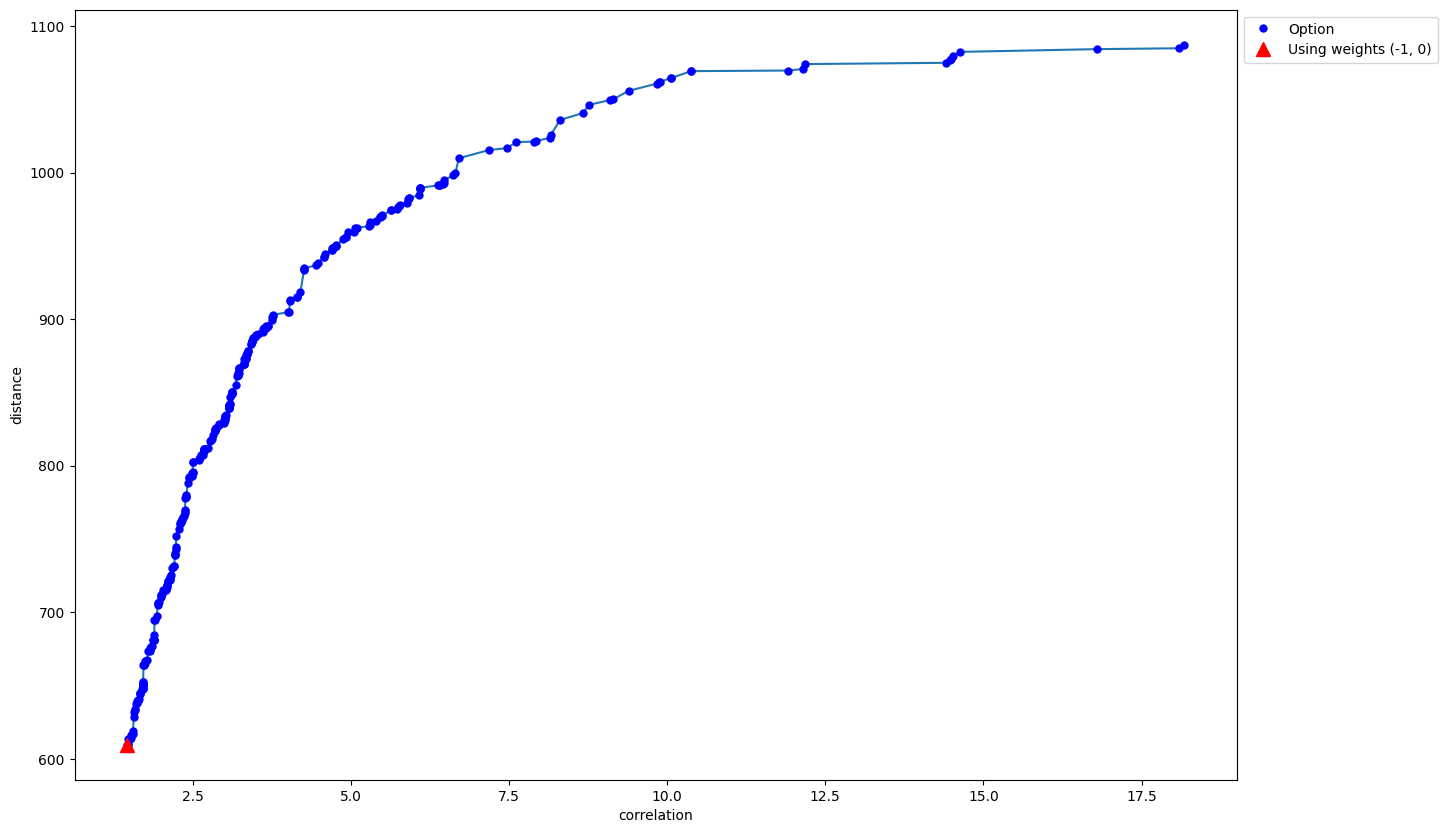

In [10]:
ag.plot(weights=(-1,0))

### Spatial Step

In [11]:
data_bulk = pd.DataFrame(st_adata.X.transpose()) #.to_array() for real datasets.
data_bulk.index = st_adata.var_names.to_list()

In [13]:
coef = ag.deconvolve(data_bulk.T) 
print(coef)

[[ 8.29336846e-05  2.56454697e-05 -6.32527234e-05 ...  3.55514644e-05
   2.12390481e-05  7.25839799e-05]
 [ 2.53475699e-04  1.24677229e-05  2.90770006e-05 ...  7.25069472e-05
   1.08835738e-04  1.55392227e-04]
 [ 9.38827745e-05  8.53355137e-06  5.71166007e-05 ...  5.06789519e-05
   9.18454816e-05  2.36327158e-05]
 ...
 [ 1.59592901e-01  4.98310561e-01  9.93825203e-02 ...  7.13489566e-01
  -3.82300593e-03  1.17598645e-01]
 [ 2.19691534e-01  4.86600338e-01  2.64058737e-01 ...  4.42193266e-01
  -4.25668292e-03  1.44210157e-01]
 [ 1.49291503e-04  1.22503478e-04 -8.41885788e-05 ...  7.61847859e-05
   1.80750305e-05  4.24373232e-05]]


In [14]:
df = pd.DataFrame(coef, columns = sc_ag.obs_names)
df["spot_id"] = st_adata.obs_names.values
cols = df.columns.tolist()
cols = [cols[-1]] + cols[:-1]
df = df[cols]
print (df)
df.to_csv(output_path + "output_Autogenes.csv")

In [20]:
df

,spot_id,fibroblasts,basal,lumhr,lumsec,vascular,pericytes,myeloid,bcells,lymphatic,tcells
0,AAACAGCTTTCAGAAG-1_10,0.000083,0.000026,-0.000063,0.000099,-0.000027,0.000062,0.000080,0.000036,0.000021,0.000073
1,AAACAGGGTCTATATT-1_10,0.000253,0.000012,0.000029,0.000070,0.000015,0.000027,0.000067,0.000073,0.000109,0.000155
2,AAACAGTGTTCCTGGG-1_10,0.000094,0.000009,0.000057,-0.000036,-0.000003,-0.000038,0.000083,0.000051,0.000092,0.000024
3,AAACATGGTGAGAGGA-1_10,0.559208,0.800634,0.255881,0.512625,0.087250,0.038369,0.119754,1.105967,0.171778,-0.013805
4,AAACATTTCCCGGATT-1_10,0.000101,0.000032,0.000021,0.000023,0.000041,0.000018,0.000031,0.000003,0.000003,-0.000067
...,...,...,...,...,...,...,...,...,...,...,...
2796,TTGTTCTAGATACGCT-1_10,0.000078,0.000007,0.000030,0.000060,-0.000025,0.000038,0.000031,0.000082,0.000079,-0.000037
2797,TTGTTGTGTGTCAAGA-1_10,0.000013,0.000154,0.000064,0.000030,0.000063,-0.000035,0.000021,0.000115,0.000050,0.000038
2798,TTGTTTCACATCCAGG-1_10,0.159593,0.498311,0.099383,1.046783,-0.020903,0.075167,0.102367,0.713490,-0.003823,0.117599
2799,TTGTTTCATTAGTCTA-1_10,0.219692,0.486600,0.264059,1.617839,-0.024724,0.019934,0.190924,0.442193,-0.004257,0.144210
